In [2]:
# https://chatgpt.com/share/6a780947-b490-83ea-96f8-7065b10e8b5b

# Exercise: build your classifier from scratch

from sklearn.datasets import load_iris
import numpy as np

# Load Iris dataset
iris = load_iris()

# Features
X = iris.data

# Original labels:
# 0 = setosa
# 1 = versicolor
# 2 = virginica
y_original = iris.target

# Convert to binary classification:
# Setosa     -> 1
# Not Setosa -> 0
y = (y_original == 0).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 10 X:")
print(X[:10])

print("\nFirst 10 y:")
print(y[:10])

print("\nClass distribution:")
print(np.bincount(y))

X shape: (150, 4)
y shape: (150,)

First 10 X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]

First 10 y:
[1 1 1 1 1 1 1 1 1 1]

Class distribution:
[100  50]


y = 0 → Not Setosa → 100 samples
y = 1 → Setosa → 50 samples


np.bincount(y)
       ↓
[100, 50]
   ↑    ↑
count  count
of 0   of 1

   # matrix multiplication of X and weights 
    # X                           w[1:]

    [SL, SW, PL, PW]          @      [w1, w2, w3, w4]
    [SL, SW, PL, PW]
    [SL, SW, PL, PW]
    ...
    For one sample, it calculates:SL⋅w1+SW⋅w2+PL⋅w3+PW⋅w4
    The bias is added z = w[0] + X @ w[1:]
	​


In [17]:
import numpy as np

def sigmoid_func(x):
    return 1 / (1 + np.exp(-x))


def model_predict(X, w):
    # w[0] = bias
    # w[1:] = weights for the 4 features
    
    z = w[0] + X @ w[1:]   # matrix multiplication of X and weights       
    
  
    return sigmoid_func(z)


def get_sig_error_loss(X, y, w):
    y_pred = model_predict(X, w)
    
    # Both y and y_pred have shape (number_of_samples,)
    return np.mean((y - y_pred) ** 2)


def getSigmoidGradient(X, y, w):
    
    # Calculate the original loss
    base_error = get_sig_error_loss(X, y, w)
    
    # Small amount used to estimate the derivative
    delta = 0.0001
    
    # Create an array to store gradients
    gradient = np.zeros(len(w))
    
    # Calculate gradient for EVERY weight
    for i in range(len(w)):
        
        # Copy the current weights
        new_w = w.copy()
        
        # Increase one weight by delta
        new_w[i] = new_w[i] + delta
        
        # Calculate the new loss
        new_loss = get_sig_error_loss(X, y, new_w)
        
        # Estimate the gradient
        gradient[i] = (new_loss - base_error) / delta
    
    return gradient

 Patience is how many iterations you allow the model to continue training without improvement before stopping. For example: patience = 100 it means 

If the loss improves → reset the counter to 0
If the loss does not improve → increase the counter
If there are 100 consecutive iterations without improvement → stop training
                    Loss improved?
                         │
                 ┌───────┴───────┐
                YES             NO
                 │               │
     patience_counter = 0    counter += 1
                 │               │
                 │        counter >= patience?
                 │               │
                 │          YES → STOP
                 │
          Continue training

In [18]:
def fit_model(X, y, w_initial, eta=0.01, num_iterations=20000,
              patience=1000, min_delta=1e-8, print_every=500):

    # Start with the initial weights
    w = w_initial.astype(float).copy()

    # Variables for early stopping
    best_loss = float('inf') # Set best_loss to positive infinity initially. if current loss is 0.65 0.65 < ∞   → True the first loss is saved:best_loss = 0.65
    best_weights = w.copy()
    patience_counter = 0

    # Store training history
    error_history = []

    for i in range(1, num_iterations + 1):

        # 1. Calculate gradient
        gradient = np.array(getSigmoidGradient(X, y, w))

        # 2. Update weights using gradient descent
        w = w - eta * gradient

        # 3. Calculate current loss
        current_loss = get_sig_error_loss(X, y, w)

        # 4. Save loss history
        error_history.append(current_loss)

        # 5. Check for improvement
        if current_loss < best_loss - min_delta:

            # We found a better model
            best_loss = current_loss
            best_weights = w.copy()

            # Reset patience
            patience_counter = 0

        else:
            # No meaningful improvement
            patience_counter += 1

        # 6. Print training progress
        if i == 1 or i % print_every == 0:
            print(
                f"Iteration {i:5d} | "
                f"Weights: {w} | "
                f"Loss: {current_loss:.8f} | "
                f"Patience: {patience_counter}/{patience}"
            )

        # 7. Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping at iteration {i}")
            break

    # Return the best weights, not necessarily the last weights
    return best_weights, error_history

In [ ]:
learning rate

In [20]:
#initalize weights
w_initial = np.array([0.1, 0.1, 0.1, 0.1, 0.1])  # [bias, slope]
best_weights,error_history = fit_model(X, y, w_initial)
best_weights

Iteration     1 | Weights: [0.09881626 0.09228277 0.09679576 0.09325144 0.09762971] | Loss: 0.47884131 | Patience: 0/1000
Iteration   500 | Weights: [ 0.15250818  0.06955534  0.43246159 -0.66425386 -0.23480425] | Loss: 0.04452768 | Patience: 0/1000
Iteration  1000 | Weights: [ 0.18415685  0.1263855   0.59872455 -0.91129014 -0.34665208] | Loss: 0.02268738 | Patience: 0/1000
Iteration  1500 | Weights: [ 0.20244446  0.15748156  0.69669776 -1.05892174 -0.4131106 ] | Loss: 0.01516578 | Patience: 0/1000
Iteration  2000 | Weights: [ 0.215238    0.17869032  0.76600319 -1.16394728 -0.46037734] | Loss: 0.01140409 | Patience: 0/1000
Iteration  2500 | Weights: [ 0.22505485  0.19472886  0.81959846 -1.24542855 -0.49710324] | Loss: 0.00915206 | Patience: 0/1000
Iteration  3000 | Weights: [ 0.23300913  0.20760361  0.86328685 -1.31199469 -0.52717129] | Loss: 0.00765337 | Patience: 0/1000
Iteration  3500 | Weights: [ 0.23968982  0.21834811  0.90016091 -1.36827159 -0.55265266] | Loss: 0.00658402 | Patien

array([ 0.31315442,  0.33483858,  1.31609332, -2.00872584, -0.84960401])

In [ ]:
y.shape
y.reshape(-1, 1)


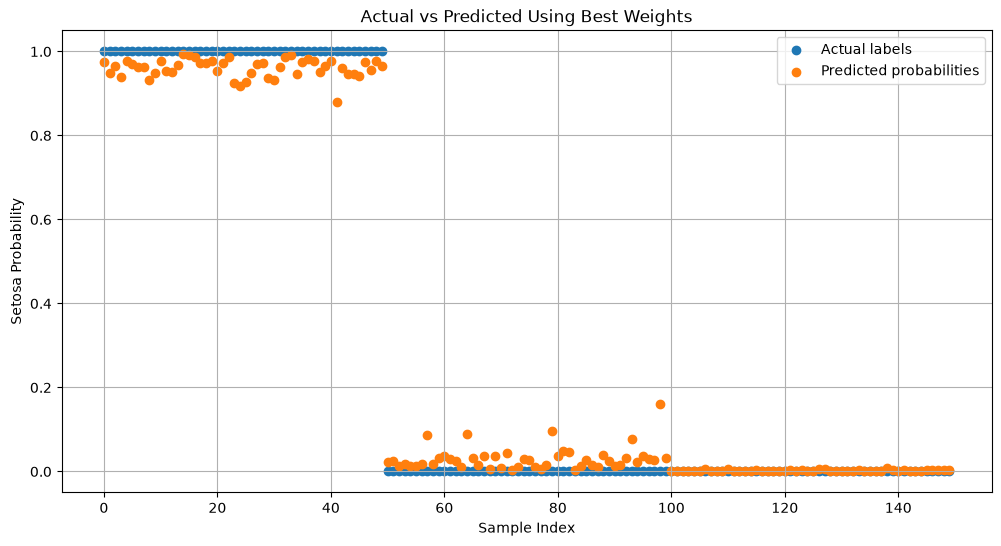

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Predict using the trained/best weights
y_pred = model_predict(X, best_weights)

# Sample numbers: 0, 1, 2, ..., 149
samples = np.arange(len(y))

plt.figure(figsize=(12, 6))

# Actual labels
plt.scatter(samples, y, label="Actual labels")

# Predicted probabilities using best_weights
plt.scatter(samples, y_pred, label="Predicted probabilities")

plt.xlabel("Sample Index")
plt.ylabel("Setosa Probability")
plt.title("Actual vs Predicted Using Best Weights")
plt.legend()
plt.grid()
plt.show()

In [ ]:
Sepal/petal length/width -> M1 -> setosa or not setosa (0.9 - means 90% setosa and 10% for not setosa)

Sepal/petal length/width -> M2 -> viginica or not virginica
Sepal/petal length/width -> M3 -> versicolor or not versicolor


Sepal/petal length/width -> M -> setosa, virgina, versicolor


# x = [sepal_len, sepal_w, petal_l, petal_w]
def M(x):
    probs = [M1(x), M2(x), M3(x)]
    labels = ["setosa", "viginica", "versicolor"]
    idx = argmax(probs) # weighted probabilities
    return labels[idx]

In [ ]:
def M(x):
    probs = [M1(x), M2(x), M3(x)]
    probs = probs/sum(probs)
    labels = ["setosa", "viginica", "versicolor"]
    idx = argmax(probs) # weighted probabilities
    return labels[idx]

In [30]:
import random 
items = ['Common Sword', 'Rare Amulet', 'Epic Ring']
probs = [.7, .1, .2]

result = []
for _ in range(1000):
    r = random.choices(items, weights=probs, k=1)[0]
    result.append(r)


counts = Counter(result)
counts 


Counter({'Common Sword': 698, 'Epic Ring': 203, 'Rare Amulet': 99})

In [ ]:
# If probs are [.4999, .501, 0.000001]
def weighted_chances(probs):
    # returns 0 49.99% 
    # return 1 50.1 % tiems
    # return 2 0.001 times
    

In [11]:
def biased_coin_toss(prob_head):
    r = random.random()
    if r < prob_head:
        return "head"
    else:
        return "tail"

In [19]:
result = []
for _ in range(100000):
    result.append(biased_coin_toss(.9))

In [22]:
from collections import Counter
counts = Counter(result)
counts['head']/(counts['head'] + counts['tail'])

0.90091

In [ ]:
biased_coin_toss(.9) # it would give Head 90 out of 100 times approx

In [10]:
import random 
random.random()

0.431305405876821

In [ ]:
def fair_coint_toss():
    # return "head" or "tail"
    r = random.random()
    if r < 0.5:
        return "head"
    else:
        return "tail"

In [ ]:
# Given the characterstics of the flower, give me probabilities of the three classes
def M(x):
    probs = [M1(x), M2(x), M3(x)]

    probs = probs/sum(probs)
    return probs

In [9]:
import numpy as np 

arr = np.array([.69, .71, .1])
arr = np.exp(10*arr)
arr / sum(arr)

array([0.44961154, 0.54915677, 0.00123169])

In [ ]:
# x = [sepal_len, sepal_w, petal_l, petal_w]
def M(x):
    if M1(x) > 0.5:
        
    # probs = [M1(x), M2(x), M3(x)]
    # labels = ["setosa", "viginica", "versicolor"]
    # idx = argmax(probs)
    # return labels[idx]